<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/gradient_descent_part1_New_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Approach
# **Gradient Descent for Linear Regression. Part 1/2**
#### **Understanding the Algorithm and Basic Implementation**  


 <a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

> **Esta es la Parte 1 de 2 en nuestra serie sobre Gradient Descent.**
> Aquí aprenderás la intuición, las matemáticas esenciales y la implementación básica del algoritmo. En la Parte 2 abordaremos los hiperparámetros, el escalado de características y las implementaciones profesionales.

Si quieres repasar los fundamentos de la regresión lineal y el método de mínimos cuadrados, te recomiendo leer primero mi artículo [Linear Regression from Scratch in Python](https://www.kaggle.com/code/magnitopic/linear-regression-from-scratch-in-python-part-1-2), donde se abordan estos conceptos desde cero.

### El algoritmo estrella del Machine Learning

El Descenso del Gradiente es el motor de optimización detrás de prácticamente todo el Machine Learning moderno. En este artículo, aprenderás cómo funciona este algoritmo aplicándolo a la Regresión Lineal, combinando teoría accesible con código práctico para que entiendas **por qué funciona** y **cómo implementarlo** paso a paso.

Al final de este artículo, habrás construido tu propio algoritmo de Gradient Descent desde cero y entenderás la base sobre la que se construyen las redes neuronales.

---

## **1. Introducción: ¿Qué problema queremos resolver?**

En el corazón del Machine Learning se encuentra una tarea fundamental: la **predicción**. Queremos usar datos que ya tenemos para hacer estimaciones inteligentes sobre datos que aún no hemos visto.

Tomemos un ejemplo clásico y práctico: **predecir el precio de una vivienda basándonos en su tamaño**.

### El problema de predicción

Imagina que dispones de un conjunto de datos de casas. Para cada una conoces su **tamaño en metros cuadrados** (nuestra variable de entrada $x$) y el **precio de venta** (nuestra variable objetivo $y$). Si representamos estos datos en un gráfico de dispersión, veremos una nube de puntos con una tendencia clara: a mayor área, mayor precio (aunque con cierta dispersión).

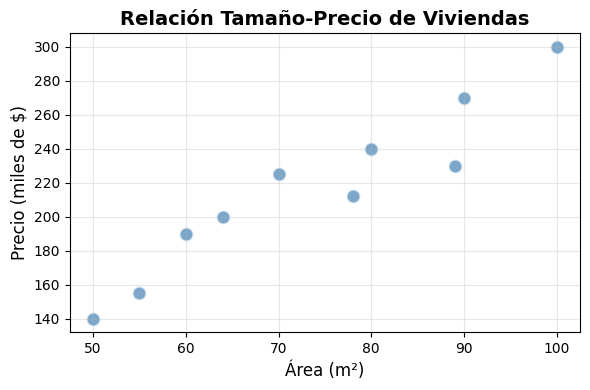

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo: tamaño de vivienda vs precio
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
precio = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

plt.figure(figsize=(6, 4))
plt.scatter(area, precio/1000, alpha=0.7, s=100, color='steelblue', edgecolors='white', linewidth=1.5)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio (miles de $)', fontsize=12)
plt.title('Relación Tamaño-Precio de Viviendas', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Nuestro objetivo es encontrar **una línea recta** que capture lo mejor posible esta tendencia. Esta línea será nuestro modelo de **Regresión Lineal**.

¿Por qué esto es interesante? Porque una vez entrenado el modelo, si nos dan el área de una nueva casa ($x$), podremos usar la línea para **estimar** su precio probable ($\hat{y}$).

### La ecuación del modelo

La ecuación de una recta es bien conocida:

$$\hat{y} = w_0 + w_1 x$$

Donde:
- $x$: área de la vivienda es nuestra variable de entrada (el *feature*).
- $\hat{y}$: precio estimado es la predicción de nuestro modelo. La distinguimos de la $y$ real (el precio de venta verdadero).
- $w_0$: **intercepto** o sesgo (bias). Valor de $\hat{y}$ cuando $x = 0$.
- $w_1$: **pendiente** o peso (weight). Cuánto aumenta el precio por cada metro cuadrado adicional.

**Objetivo:** Encontrar los parámetros $ w_0 $ y $ w_1 $ que nos den la recta que mejor se ajuste a la nube de puntos.

Existen dos enfoques principales:

1. **Solución cerrada (Ecuación Normal)**  
   Una fórmula analítica directa:  
   $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$  
   Es exacta y rápida para datasets pequeños, pero se vuelve muy costosa (y a veces imposible) con millones de datos o miles de variables.

2. **Descenso del Gradiente (Gradient Descent)**  
   Un algoritmo iterativo que "camina" hacia los valores óptimos ajustando progresivamente los parámetros.  
   **Ventajas clave:**
   - Escala a datasets enormes y a miles de características
   - Funciona con datos que no caben en memoria (procesamiento por lotes)
   - Es la base de prácticamente todo el Deep Learning
   - Permite actualización continua del modelo (online learning)
   - Funciona para problemas no lineales y redes neuronales

En problemas reales (cientos de miles o millones de observaciones), la solución cerrada simplemente no es viable. Por eso necesitamos entender y dominar el **Descenso del Gradiente**.

### ¿Qué aprenderás en esta Parte 1?

- La intuición detrás del algoritmo.
- Cómo medir el error de una recta: la **función de costes**.
- Las matemáticas esenciales: qué es el gradiente y por qué “descender” nos lleva al mínimo.
- Implementar Gradient Descent desde cero con NumPy.
- Visualizar el proceso de optimización y entender qué ocurre internamente en cada paso.

En la **Parte 2** profundizaremos en:
- hiperparámetros críticos (learning rate)
- escalado de características
- variantes del algoritmo (Batch, Mini-Batch, SGD)
- comparación con implementaciones profesionales como scikit-learn.

Pero antes de implementar nada, necesitamos responder una pregunta fundamental: ¿cómo medimos qué tan "buena" o "mala" es una recta? Para eso, introduciremos la Función de Costes.

## **2. Midiendo el Error: La Función de Costes**

Para encontrar la "mejor" recta, necesitamos una forma objetiva de medir qué tan bien se ajusta una línea a los datos.

### El resíduo: el error en un punto

Para cada vivienda $i$, conocemos su área real $x_i$ y su precio real $y_i$. Nuestra recta predice un precio $\hat{y}_i = w_0 + w_1 x_i$.

La diferencia vertical entre el punto real y la predicción se llama **residuo**:

$$e_i = y_i - \hat{y}_i$$

- Si $e_i > 0$, el punto está por encima de la recta (subestimamos el precio).
- Si $e_i < 0$, el punto está por debajo (sobreestimamos).

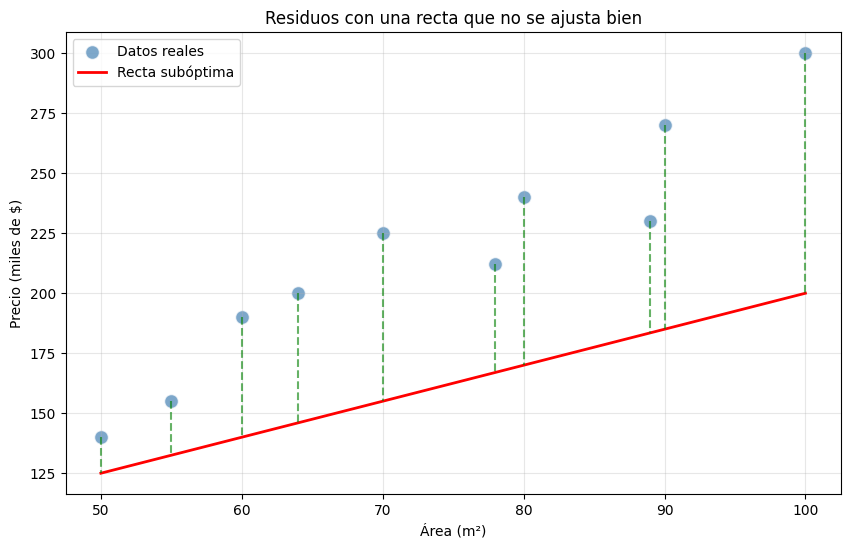

In [2]:
# Visualización rápida de residuos con una recta arbitraria
w0_bad, w1_bad = 50000, 1500
y_pred_bad = w0_bad + w1_bad * area

plt.figure(figsize=(10, 6))
plt.scatter(area, precio/1000, s=100, alpha=0.7, color='steelblue', edgecolors='white', label='Datos reales')
plt.plot(area, y_pred_bad/1000, 'r-', linewidth=2, label='Recta subóptima')
for i in range(len(area)):
    plt.plot([area[i], area[i]], [precio[i]/1000, y_pred_bad[i]/1000], 'g--', alpha=0.6)
plt.xlabel('Área (m²)')
plt.ylabel('Precio (miles de $)')
plt.title('Residuos con una recta que no se ajusta bien')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### El error total: ¿por qué no basta con sumar los residuos?

Un impulso inicial sería sumar todos los residuos. Pero esto es problemático: los errores positivos y negativos se cancelan, pudiendo dar la falsa impresión de que no hay error cuando en realidad la recta está muy alejada de muchos puntos.

### Solución: Error Cuadrático Medio (MSE)

Para evitar cancelaciones y penalizar más los errores grandes:

1. Elevamos cada residuo al cuadrado: $e_i^2 = (y_i - \hat{y}_i)^2$
    - siempre positivo
    - penaliza los errores grandes mucho más
2. Calculamos la media de todos los errores al cuadrado que es la **Mean Squared Error (MSE)**.

Esta métrica es nuestra **Función de Costes** $J$:

$$J(w_0, w_1) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 = \frac{1}{m} \sum_{i=1}^{m} (y_i - (w_0 + w_1 x_i))^2$$

donde $m$ es el número de datos.

> **Nota:** En algunos textos verás $\frac{1}{2m}$ en lugar de $\frac{1}{m}$. El factor $\frac{1}{2}$ solo simplifica las derivadas posteriores, pero no cambia la posición del mínimo.

In [3]:
def mse(w0, w1, x, y):
    """Calcula el Error Cuadrático Medio"""
    m = len(y)
    y_pred = w0 + w1 * x
    return (1/m) * np.sum((y - y_pred)**2)

# Calculamos el MSE para nuestra línea subóptima
mse_bad = mse(w0_bad, w1_bad, area, precio)
rmse_bad = np.sqrt(mse_bad)

print(f"MSE con la recta subóptima: {mse_bad:,.0f}")
print(f"RMSE (raíz del MSE): ${rmse_bad:,.0f}")
print(f"En promedio, las predicciones se desvían unos ${rmse_bad:,.0f} del precio real")

MSE con la recta subóptima: 3,735,950,000
RMSE (raíz del MSE): $61,122
En promedio, las predicciones se desvían unos $61,122 del precio real


### El nuevo objetivo

Los datos $x$ e $y$ son fijos. Por tanto, $J$ no depende de $x$, depende solo de los parámetros $w_0$ y $w_1$.

- Diferentes valores de $w_0$ y $w_1$ (diferentes líneas) nos darán un coste $J$ diferente.
- Una línea mala tendrá un coste $J$ muy alto.
- Una línea buena tendrá un coste $J$ muy bajo.
- **La línea perfecta** minimizará $J$.

Si representamos $J(w_0, w_1)$ en un gráfico 3D, obtenemos una superficie con forma de cuenco (convexa). Nuestro problema se reduce a encontrar el punto más bajo de ese cuenco. Es un problema de minimización.

El algoritmo que nos llevará hasta el fondo del valle es el **Descenso del Gradiente**, que veremos en la siguiente sección.

## **3. El Algoritmo: Descenso del Gradiente**

Ahora que sabemos que nuestro objetivo es minimizar la función de costes $J(w_0, w_1)$, necesitamos un método para llegar al fondo del "cuenco". El **Descenso del Gradiente** es ese método.

### La Analogía del Montañero perdido en la niebla

Imagina que estás en la ladera de una montaña y hay una densa niebla que hace que tu visibilidad sea muy escasa. Quieres llegar al fondo del valle, pero no puedes ver el terreno completo, aunque sí puedes sentir la pendiente bajo tus pies.

Tu estrategia para descender sería:

1. Te detienes y palpas el suelo para determinar la dirección de **máximo descenso** (la pendiente más pronunciada hacia abajo).
2. Das un paso en esa dirección.
3. Repites el proceso hasta que el terreno se vuelva plano y ya no puedas bajar más. En ese punto has llegado al valle.

Esto es precisamente lo que hace el Descenso del Gradiente:

| Montañero con niebla | Descenso del Gradiente |
|:----------------|:-----------------------|
| Posición en la montaña | Valores actuales de $w_0$ y $w_1$ |
| Altura sobre el nivel del mar | Valor de la función de costes $J(w_0, w_1)$ |
| Palpar la pendiente local del terreno | Calcular el **gradiente** de $J$ |
| Dirección de máxima pendiente hacia abajo | Dirección opuesta al gradiente |
| Longitud del paso | **Tasa de aprendizaje** ($\alpha$) |
| Terreno plano (valle) | Mínimo de $J$ (gradiente ≈ 0) |
| Caminar paso a paso | **Iteraciones** del algoritmo |

**Lo crucial de esta analogía:** El montañero no se desliza sin control. Se **detiene en cada paso**, evalúa la pendiente local, y **decide conscientemente** hacia dónde moverse. Es un proceso iterativo **discreto y controlado**, no continuo. El Descenso del Gradiente hace exactamente esto.

### Los dos componentes clave

El algoritmo se basa en dos ideas: El gradiente y la tasa de aprendizaje.

### A. El Gradiente: la dirección de máximo crecimiento

El gradiente $\nabla J$ (nabla de $J$) es un vector que contiene las derivadas parciales de $J$ respecto a cada parámetro:

$$
\frac{\partial J}{\partial w_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)
$$

$$
\frac{\partial J}{\partial w_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i
$$

**Interpretación intuitiva:**
- Ambas fórmulas calculan un **promedio de errores** (tienen $\frac{1}{m}$). La primera es un promedio simple y la segunda es un promedio ponderado con $x$.
- Si sobre-estimamos $(\hat{y}_i > y_i)$, el gradiente es positivo → debemos reducir los parámetros.
- Si sub-estimamos $(\hat{y}_i < y_i)$, el gradiente es negativo → debemos aumentar los parámetros.
- El gradiente de $w_1$ está multiplicado por $x_i$ por lo que los puntos con mayor $x$ influyen más en el ajuste de la pendiente.

Como el gradiente apunta hacia la **subida**, para descender vamos en la dirección opuesta, por eso usaremos un signo menos en la fórmula.

### B. La Tasa de Aprendizaje $\alpha$: el tamaño del paso

El *learning rate* $\alpha$ es un hiperparámetro que controla cuánto nos movemos en cada iteración.

La regla de actualización (aplicada <u>simultáneamente</u> a ambos parámetros) es:

$$
w_0 := w_0 - \alpha \cdot \frac{\partial J}{\partial w_0}
$$

$$
w_1 := w_1 - \alpha \cdot \frac{\partial J}{\partial w_1}
$$

#### ¿Qué pasa con diferentes valores de $\alpha$?

| Tasa de aprendizaje | Comportamiento | Consecuencia |
|:--------------------|:---------------|:-------------|
| **Demasiado pequeña** ($\alpha \ll 1$) | Pasos muy pequeños | ↓ Convergencia extremadamente lenta. Puede necesitar millones de iteraciones. |
| **Óptima** | Pasos ni muy grandes ni muy pequeños | ↑↑ Convergencia rápida y estable hacia el mínimo. |
| **Demasiado grande** ($\alpha \gg 1$) | Pasos muy grandes | ↓ Oscilación alrededor del mínimo o divergencia (el error aumenta). |


**Regla práctica:** Empezar con $\alpha = 0.01$. Si el coste oscila, reducirlo; si converge muy lento, aumentarlo ligeramente.

### Descripción del algoritmo

1. Inicializar $w_0$ y $w_1$ (normalmente en 0 o valores aleatorios pequeños).
2. Elegir $\alpha$ y un número máximo de iteraciones.
3. Repetir hasta convergencia o alcanzar el límite:
   - Calcular predicciones $\hat{y}_i = w_0 + w_1 x_i$
   - Calcular el gradiente (las dos derivadas parciales)
   - Actualizar simultáneamente $w_0$ y $w_1$:
        - w₀ := w₀ - α × (∂J/∂w₀)
        - w₁ := w₁ - α × (∂J/∂w₁)
   - (Opcional) Calcular y guardar el coste J actual para visualizar la convergencia
4. Devolver w₀ y w₁ finales

**Criterios de convergencia típicos:**
* Número fijo de iteraciones (ej. 1000 iteraciones)
* Cuando el cambio en el coste $J$ entre iteraciones es muy pequeño (ej. $10^{-4}$)
* Cuando el gradiente es casi cero (estamos en un punto plano)

Eso es todo. No hay más magia matemática.

### Nota sobre el Cálculo Simultáneo

Es vital entender que, dentro de cada paso (cada época), las actualizaciones de $w_0$ y $w_1$ deben realizarse **simultáneamente**.

Esto significa que primero se deben calcular *ambas* derivadas (gradientes) utilizando los valores de $w_0$ y $w_1$ de la *iteración anterior*. Una vez que se tienen los dos gradientes, se actualizan ambos parámetros a sus nuevos valores. Si se actualizara $w_0$ y luego se usara el *nuevo* $w_0$ para calcular la derivada de $w_1$, se introduciría un sesgo en el algoritmo que podría llevar a resultados incorrectos.

En la siguiente sección implementaremos este algoritmo desde cero en Python, normalizaremos los datos para usar una $\alpha$ razonable y visualizaremos cómo los parámetros "descienden" hacia el mínimo coste.

---

## **4. Implementación del Algoritmo**

Llegó el momento de pasar de la teoría a la práctica: implementaremos el Descenso del Gradiente desde cero usando NumPy.

### Por qué normalizamos los datos (escalado de características)

Sin normalización, la característica *área* está en un rango de ~50-100 m², mientras que los precios están en cientos de miles. Esto hace que la superficie de costes sea muy alargada y asimétrica.

Consecuencia: los gradientes para $w_1$ son mucho más grandes que para $w_0$, obligándonos a usar una tasa de aprendizaje $\alpha$ extremadamente pequeña (ej. $10^{-8}$) para evitar divergencia → Esto supone una convergencia lentísima.

Imagina un modelo con varias $x$ (features), en este caso, el impacto de $\alpha$ es particularmente sensible cuando las características de entrada tienen rangos de valores muy diferentes. De hecho, esta sensibilidad extrema es la razón principal por la que la **normalización de características** es un paso obligatorio en la práctica, ya que permite usar un $\alpha$ más grande sin riesgo de divergencia.

**Solución:** Normalizamos la entrada con **StandardScaler** (z-score): restamos la media y dividimos por la desviación estándar.

$$x_{\text{escalado}} = \frac{x - \mu}{\sigma}$$

Donde:
- $\mu$ es la media de $x$
- $\sigma$ la desviación estándar de $x$

Escalando logramos que la media sea 0 y la desviación estándar sea 1, haciendo la superficie de costes más redonda y permitiendo usar $\alpha = 0.01$ (mucho más grande y eficiente).

In [4]:
from sklearn.preprocessing import StandardScaler

# Normalizar área
scaler = StandardScaler()
X_scaled = scaler.fit_transform(area.reshape(-1, 1)).flatten()

# Guardar parámetros para desnormalizar después
mu, sigma = scaler.mean_[0], scaler.scale_[0]

print(f"Media μ = {mu:.2f} m²")
print(f"Desviación σ = {sigma:.2f} m²")
print(f"Ejemplo: \n\tárea  50 m² → escalado {X_scaled[0]:.2f}")
print(f"\tárea 100 m² → escalado  {X_scaled[-1]:.2f}")

Media μ = 73.60 m²
Desviación σ = 15.67 m²
Ejemplo: 
	área  50 m² → escalado -1.51
	área 100 m² → escalado  1.68


### El algoritmo en código

Usamos notación matricial para mayor claridad y eficiencia:

- Añadimos una columna de 1s a $X$ para incluir el sesgo.
- Los parámetros son un vector $\mathbf{w} = [w_0, w_1]$.

In [5]:
# Matriz de diseño: [1, x_escalado]
X_b = np.c_[np.ones(len(X_scaled)), X_scaled]  # forma (m, 2)

def gradient_descent(X_b, y, alpha=0.01, n_iter=1000, tol=1e-6):
    m = len(y)
    w = np.zeros(2)              # inicializar w0 y w1 en 0
    cost_history = []
    prev_cost = np.inf

    for i in range(n_iter):
        # Predicciones y error
        y_pred = X_b @ w
        error = y_pred - y

        # Gradiente (vector)
        gradient = (1/m) * X_b.T @ error

        # Actualización simultánea
        w = w - alpha * gradient

        # Coste (usamos 1/(2m) por conveniencia común)
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)

        # Early stopping opcional
        if prev_cost - cost < tol:
            print(f"Convergencia alcanzada en la iteración: {i+1}")
            break
        prev_cost = cost

    return w, cost_history

# Entrenar
w_scaled, history = gradient_descent(X_b, precio, alpha=0.01, n_iter=2000)

Convergencia alcanzada en la iteración: 1683


### Desnormalización: volver al espacio original

Los parámetros obtenidos (`w_scaled`) son válidos solo para los datos escalados. Para interpretarlos en unidades reales (dólares y m²), debemos revertir la transformación:

$$
w_1 = \frac{w_1'}{\sigma}
$$

$$
w_0 = w_0' - w_1 \cdot \mu
$$

Donde $w_0'$ y $w_1'$ son los parámetros en el espacio escalado.

In [6]:
w1_original = w_scaled[1] / sigma
w0_original = w_scaled[0] - w1_original * mu

print(f"\nModelo final (escala original):")
print(f"Precio ≈ ${w0_original:,.0f} + ${w1_original:,.0f} × Área (m²)")


Modelo final (escala original):
Precio ≈ $10,723 + $2,792 × Área (m²)


### Visualización de resultados

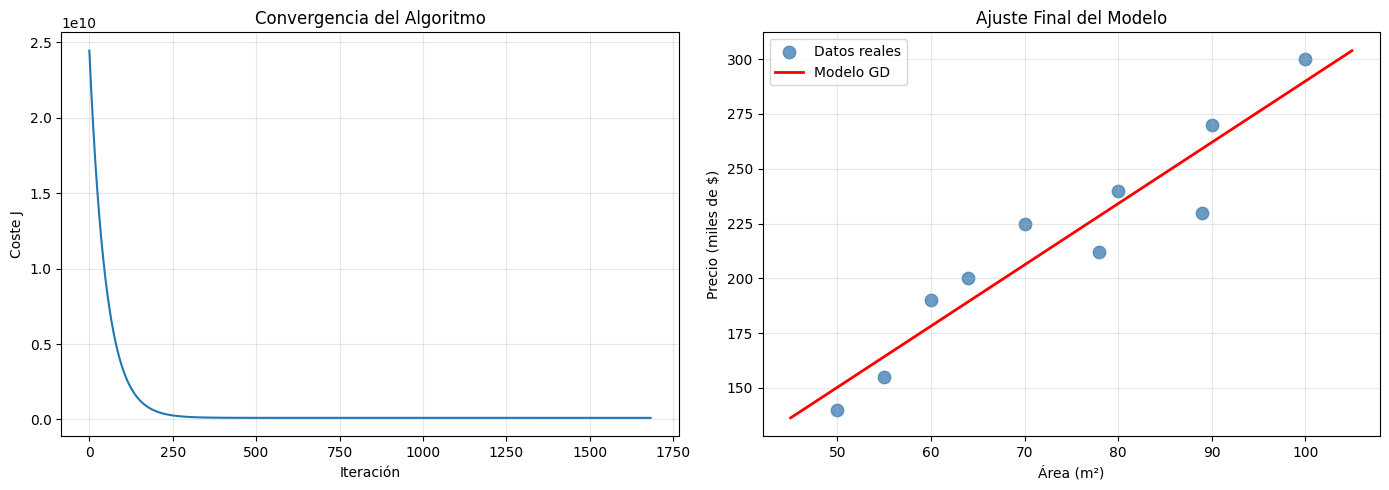


Predicción: Casa de 75 m² → $220,109


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Convergencia del coste
axs[0].plot(history)
axs[0].set_xlabel('Iteración')
axs[0].set_ylabel('Coste J')
axs[0].set_title('Convergencia del Algoritmo')
axs[0].grid(alpha=0.3)

# Modelo final vs datos
area_line = np.linspace(45, 105, 100)
precio_line = w0_original + w1_original * area_line

axs[1].scatter(area, precio/1000, s=80, color='steelblue', label='Datos reales', alpha=0.8)
axs[1].plot(area_line, precio_line/1000, 'r-', linewidth=2, label='Modelo GD')
axs[1].set_xlabel('Área (m²)')
axs[1].set_ylabel('Precio (miles de $)')
axs[1].set_title('Ajuste Final del Modelo')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ejemplo de predicción
area_nueva = 75
pred = w0_original + w1_original * area_nueva
print(f"\nPredicción: Casa de {area_nueva} m² → ${pred:,.0f}")

¡Listo! Has implementado Gradient Descent desde cero y obtenido un modelo funcional. En la Parte 2 exploraremos hiperparámetros, variantes más avanzadas (Mini-Batch, SGD) y comparación con scikit-learn.